# SAM3 Pallet OBB Pipeline
Image → SAM3 segmentation → 2D mask → back-project to 3D (depth + intrinsics) → Oriented Bounding Box

In [15]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
SAM3_ROOT = PROJECT_ROOT / "sam3"

# Make the local sam3 package importable if it is not installed in the environment.
if str(SAM3_ROOT) not in sys.path:
    sys.path.insert(0, str(SAM3_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"SAM3 root: {SAM3_ROOT}")

Project root: /home/burak/projects/sightai
SAM3 root: /home/burak/projects/sightai/sam3


## Import Libraries

In [16]:
import subprocess

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

import sam3
from sam3 import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import plot_results

try:
    import open3d as o3d
except ImportError:
    print("Installing open3d...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "open3d", "-q"])
    import open3d as o3d

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## Configuration & Parameters

In [17]:
INPUT_DIR = Path("data/picaulo/capture4")
IMAGE_PATH = INPUT_DIR / "rgb.png"
DEPTH_MAP_PATH = INPUT_DIR / "depth_mm.npy"

BPE_PATH = Path("/home/burak/projects/sightai/sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz")

# Create all outputs inside the selected input folder.
IMAGE_RESULT_DIR = INPUT_DIR / "outputs"

CAMERA_INTRINSICS = {
    'fx': 1113.178,
    'fy': 1112.932,
    'cx': 660.693,
    'cy': 473.587,
    'width': 1280,
    'height': 960,
}

NAMING_PROMPT = "pallet"
CORNER_EPSILON_FACTOR = 0.02

# Only keep pallets whose contour has exactly 4 corners all within the image frame.
REQUIRE_FULL_VISIBILITY = True

paths_to_check = [
    (INPUT_DIR,      "Input folder"),
    (IMAGE_PATH,     "RGB image"),
    (DEPTH_MAP_PATH, "Depth map"),
    (BPE_PATH,       "BPE tokenizer"),
]

print("Data paths:")
for path, name in paths_to_check:
    status = "✓" if path.exists() else "✗"
    print(f"  {status} {name}: {path}")
    if not path.exists():
        raise FileNotFoundError(f"{name} not found: {path}")

# Ensure output directory exists.
IMAGE_RESULT_DIR.mkdir(parents=True, exist_ok=True)

print(f"\nOutput dir: {IMAGE_RESULT_DIR}/")
print(f"\nCamera intrinsics: fx={CAMERA_INTRINSICS['fx']}, fy={CAMERA_INTRINSICS['fy']}, "
      f"cx={CAMERA_INTRINSICS['cx']}, cy={CAMERA_INTRINSICS['cy']}")


Data paths:
  ✓ Input folder: data/picaulo/capture4
  ✓ RGB image: data/picaulo/capture4/rgb.png
  ✓ Depth map: data/picaulo/capture4/depth_mm.npy
  ✓ BPE tokenizer: /home/burak/projects/sightai/sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz

Output dir: data/picaulo/capture4/outputs/

Camera intrinsics: fx=1113.178, fy=1112.932, cx=660.693, cy=473.587


## Utility Functions

In [18]:
def extract_masks_from_inference(inference_state: dict) -> np.ndarray:
    if "masks" not in inference_state or inference_state["masks"] is None:
        raise ValueError("No masks found in inference_state")
    masks = inference_state["masks"]
    if isinstance(masks, torch.Tensor):
        masks_np = masks.detach().float().cpu().numpy()
    else:
        masks_np = np.asarray(masks)
    if masks_np.ndim == 4 and masks_np.shape[1] == 1:
        masks_np = masks_np[:, 0]
    elif masks_np.ndim != 3:
        raise ValueError(f"Unexpected masks shape: {masks_np.shape}")
    return masks_np


def project_to_2d(pts_3d, intrinsics):
    """Back-project 3D camera-space points to pixel coordinates."""
    fx, fy = intrinsics['fx'], intrinsics['fy']
    cx, cy = intrinsics['cx'], intrinsics['cy']
    pts = np.asarray(pts_3d)
    u = (pts[:, 0] * fx / pts[:, 2] + cx).astype(int)
    v = (pts[:, 1] * fy / pts[:, 2] + cy).astype(int)
    return np.stack([u, v], axis=1)


def extract_corner_coordinates(binary_mask, epsilon_factor=0.02):
    """Extract corner pixels from a binary mask via contour approximation."""
    mask_uint8 = (binary_mask.astype(np.uint8) * 255)
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if len(contours) == 0:
        return np.array([]).reshape(0, 2)
    contour = max(contours, key=cv2.contourArea)
    epsilon = epsilon_factor * cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, epsilon, True)
    return approx.reshape(-1, 2)[:, ::-1]  # (x,y) -> (y,x)


def pixel_to_3d(pixel_coords, depth_map, intrinsics):
    """Back-project 2D pixel (y,x) coords to 3D camera-space points using depth."""
    if len(pixel_coords) == 0:
        return np.array([]).reshape(0, 3)
    fx, fy = intrinsics['fx'], intrinsics['fy']
    cx, cy = intrinsics['cx'], intrinsics['cy']
    points_3d = []
    for y, x in pixel_coords:
        if 0 <= y < depth_map.shape[0] and 0 <= x < depth_map.shape[1]:
            z = depth_map[y, x]
            if z > 0:
                points_3d.append([(x - cx) * z / fx, (y - cy) * z / fy, z])
    return np.array(points_3d)


print("✓ Utility functions defined")

✓ Utility functions defined


In [19]:
def build_corners_from_pose(center, rotation, extent):
    """Build 8 box corners from center, rotation (3x3), and extent (x,y,z lengths)."""
    c = np.asarray(center, dtype=np.float64)
    R = np.asarray(rotation, dtype=np.float64)
    e = np.asarray(extent, dtype=np.float64)
    half = 0.5 * e

    local_corners = np.array(
        [
            [-half[0], -half[1], -half[2]],
            [ half[0], -half[1], -half[2]],
            [ half[0],  half[1], -half[2]],
            [-half[0],  half[1], -half[2]],
            [-half[0], -half[1],  half[2]],
            [ half[0], -half[1],  half[2]],
            [ half[0],  half[1],  half[2]],
            [-half[0],  half[1],  half[2]],
        ],
        dtype=np.float64,
    )

    # local -> camera frame
    corners = local_corners @ R.T + c[None, :]
    return corners


def obb_to_pose(obb):
    """Return pose components from an Open3D oriented bounding box."""
    center = np.asarray(obb.center, dtype=np.float64)
    rotation = np.asarray(obb.R, dtype=np.float64)
    extent = np.asarray(obb.extent, dtype=np.float64)
    corners_3d = np.asarray(obb.get_box_points(), dtype=np.float64)
    volume_liters = float(np.prod(extent) / 1e6)  # mm^3 -> liters
    return {
        "center": center,
        "rotation": rotation,
        "extent": extent,
        "corners_3d": corners_3d,
        "volume_liters": volume_liters,
    }


def canonicalize_pallet_pose(
    pose,
    up_hint=np.array([0.0, -1.0, 0.0]),
    x_ref_hint=np.array([1.0, 0.0, 0.0]),
):
    """
    Canonical pallet frame convention:
      - X axis: long edge
      - Y axis: short edge (in-plane)
      - Z axis: upward (closest to up_hint)
      - Right-handed: X x Y = Z
    """
    R = np.asarray(pose["rotation"], dtype=np.float64)
    extent = np.asarray(pose["extent"], dtype=np.float64)

    # Sort extents: smallest->largest gives [z_idx, y_idx, x_idx] for pallet-like boxes.
    order = np.argsort(extent)
    z_idx, y_idx, x_idx = int(order[0]), int(order[1]), int(order[2])

    x_axis = R[:, x_idx].copy()
    y_axis = R[:, y_idx].copy()
    z_axis = R[:, z_idx].copy()

    def _norm(v):
        n = np.linalg.norm(v)
        return v if n < 1e-9 else v / n

    x_axis = _norm(x_axis)
    y_axis = _norm(y_axis)
    z_axis = _norm(z_axis)

    up_hint = _norm(np.asarray(up_hint, dtype=np.float64))

    # Force Z to point upward according to camera-frame up hint.
    if float(np.dot(z_axis, up_hint)) < 0.0:
        z_axis = -z_axis

    # Resolve X sign deterministically: choose +X closest to camera-right projected into pallet plane.
    x_ref_hint = _norm(np.asarray(x_ref_hint, dtype=np.float64))
    x_ref = x_ref_hint - np.dot(x_ref_hint, z_axis) * z_axis
    if np.linalg.norm(x_ref) < 1e-9:
        # Fallback if hint is nearly parallel to Z.
        x_ref_hint2 = np.array([0.0, 0.0, 1.0], dtype=np.float64)
        x_ref = x_ref_hint2 - np.dot(x_ref_hint2, z_axis) * z_axis
    x_ref = _norm(x_ref)

    if float(np.dot(x_axis, x_ref)) < 0.0:
        x_axis = -x_axis

    # Rebuild a stable right-handed basis from Z and X.
    y_axis = np.cross(z_axis, x_axis)
    if np.linalg.norm(y_axis) < 1e-9:
        y_axis = R[:, y_idx].copy()
    y_axis = _norm(y_axis)
    x_axis = _norm(np.cross(y_axis, z_axis))
    z_axis = _norm(np.cross(x_axis, y_axis))

    R_canon = np.stack([x_axis, y_axis, z_axis], axis=1)
    extent_canon = np.array([extent[x_idx], extent[y_idx], extent[z_idx]], dtype=np.float64)

    pose["rotation"] = R_canon
    pose["extent"] = extent_canon
    pose["corners_3d"] = build_corners_from_pose(pose["center"], R_canon, extent_canon)
    return pose


def build_pose_axes_points(center, rotation, axis_length_mm=250.0, origin_point=None):
    """Create 3D points for origin + axis endpoints in camera coordinates."""
    center = np.asarray(center, dtype=np.float64)
    rotation = np.asarray(rotation, dtype=np.float64)
    axis_vectors = rotation * float(axis_length_mm)

    origin = center if origin_point is None else np.asarray(origin_point, dtype=np.float64)
    x_tip = origin + axis_vectors[:, 0]
    y_tip = origin + axis_vectors[:, 1]
    z_tip = origin + axis_vectors[:, 2]

    return {
        "origin": origin,
        "x_tip": x_tip,
        "y_tip": y_tip,
        "z_tip": z_tip,
    }


def project_points_to_image(points_3d, intrinsics):
    """Project Nx3 camera-space points to image pixels with validity mask."""
    pts = np.asarray(points_3d, dtype=np.float64)
    z = pts[:, 2]
    valid = z > 1e-6

    uv = np.full((pts.shape[0], 2), -1, dtype=np.int32)
    if np.any(valid):
        fx, fy = intrinsics["fx"], intrinsics["fy"]
        cx, cy = intrinsics["cx"], intrinsics["cy"]
        u = (pts[valid, 0] * fx / pts[valid, 2] + cx).astype(np.int32)
        v = (pts[valid, 1] * fy / pts[valid, 2] + cy).astype(np.int32)
        uv[valid] = np.stack([u, v], axis=1)

    return uv, valid


def select_origin_corner(corners_3d, tol_mm=5.0):
    """Pick the origin corner using the configured axis filter."""
    corners = np.asarray(corners_3d, dtype=np.float64)
    idx = np.arange(len(corners))

    # (axis, use_max): X=max, Y=min, Z=min
    for axis, use_max in ((0, True), (1, False), (2, False)):
        vals = corners[idx, axis]
        threshold = vals.max() - tol_mm if use_max else vals.min() + tol_mm
        idx = idx[vals >= threshold] if use_max else idx[vals <= threshold]
        if len(idx) == 1:
            break

    return corners[idx[0]]


def save_points_cloud(points_xyz_mm, colors_rgb, output_path):
    """Save a small set of 3D points as a colored PLY point cloud."""
    pts = np.asarray(points_xyz_mm, dtype=np.float64).reshape(-1, 3)
    cols = np.asarray(colors_rgb, dtype=np.float64).reshape(-1, 3)

    if len(pts) == 0:
        return False

    if cols.max() > 1.0:
        cols = cols / 255.0
    cols = np.clip(cols, 0.0, 1.0)

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts)
    pcd.colors = o3d.utility.Vector3dVector(cols)
    return o3d.io.write_point_cloud(str(output_path), pcd)


def draw_pose_axes_on_image(image_bgr, axes_3d, intrinsics, label=None, thickness=3):
    """Draw XYZ pose axes on a BGR image. X=red, Y=green, Z=blue."""
    pts_3d = np.stack(
        [axes_3d["origin"], axes_3d["x_tip"], axes_3d["y_tip"], axes_3d["z_tip"]],
        axis=0,
    )
    uv, valid = project_points_to_image(pts_3d, intrinsics)

    h, w = image_bgr.shape[:2]

    # If origin is not valid/visible, skip drawing for this object.
    if not valid[0]:
        return image_bgr
    origin = tuple(uv[0].tolist())
    if not (0 <= origin[0] < w and 0 <= origin[1] < h):
        return image_bgr

    axis_specs = [
        (1, (0, 0, 255)),   # X: red
        (2, (0, 255, 0)),   # Y: green
        (3, (255, 0, 0)),   # Z: blue
    ]

    drawn_count = 0
    for idx, color in axis_specs:
        if not valid[idx]:
            continue

        tip = tuple(uv[idx].tolist())
        # Clip each axis line to the image bounds so partially visible axes still draw.
        ok, p0, p1 = cv2.clipLine((0, 0, w, h), origin, tip)
        if not ok:
            continue

        cv2.arrowedLine(image_bgr, p0, p1, color, thickness, tipLength=0.2)
        drawn_count += 1

    if drawn_count == 0:
        cv2.circle(image_bgr, origin, radius=5, color=(255, 255, 255), thickness=-1)

    if label is not None:
        cv2.putText(
            image_bgr,
            str(label),
            (origin[0] + 8, origin[1] - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 255, 255),
            2,
            cv2.LINE_AA,
        )

    return image_bgr


print("✓ Pose helper functions defined")


✓ Pose helper functions defined


## Load SAM3 Model

In [20]:
print("Loading SAM3 model...")
image_model = build_sam3_image_model(bpe_path=str(BPE_PATH))
image_processor = Sam3Processor(image_model, confidence_threshold=0.4)
print("✓ SAM3 model loaded")

Loading SAM3 model...
✓ SAM3 model loaded


## Load Input Data

In [21]:
# Load image
image = Image.open(IMAGE_PATH).convert("RGB")
image_width, image_height = image.size
print(f"✓ Image loaded: {image_width}x{image_height}")

# Load depth map
depth_mm = np.load(DEPTH_MAP_PATH)
print(f"✓ Depth map loaded: {depth_mm.shape}, range: {depth_mm.min():.0f}-{depth_mm.max():.0f} mm")

# Prepare image for inference
with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
    inference_state = image_processor.set_image(image)
print("✓ Inference state initialized")

✓ Image loaded: 1280x960
✓ Depth map loaded: (960, 1280), range: 0-2800 mm
✓ Inference state initialized


## Run SAM3 Segmentation

✓ Text prompt applied: 'pallet'
found 2 object(s)


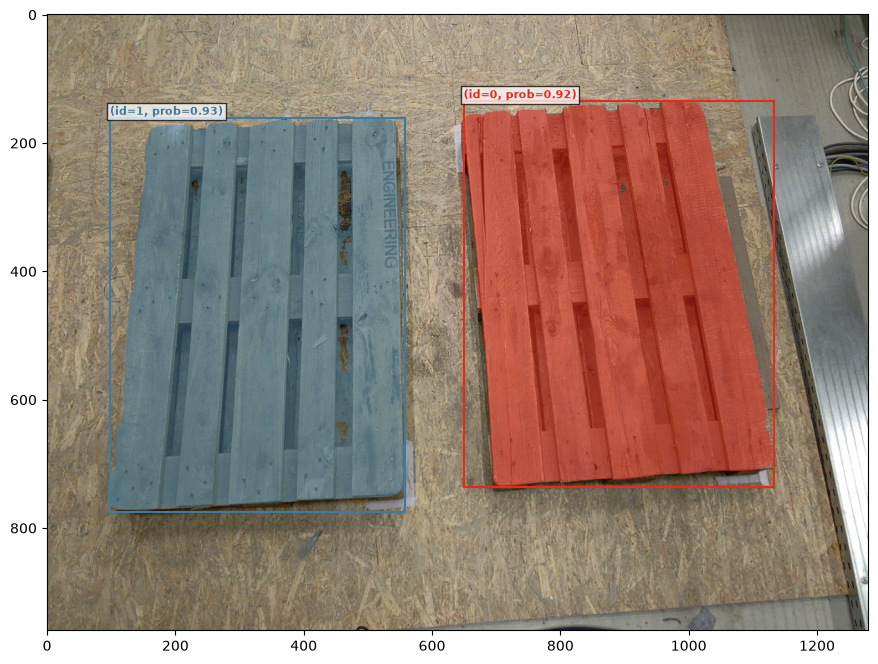

In [22]:
# Set text prompt
image_processor.reset_all_prompts(inference_state)

with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
    inference_state = image_processor.set_text_prompt(
        prompt=NAMING_PROMPT, 
        state=inference_state
    )

print(f"✓ Text prompt applied: '{NAMING_PROMPT}'")
plot_results(image, inference_state)

## Extract and Save Masks

✓ Extracted 2 mask(s)
✓ 2 object mask(s) ready


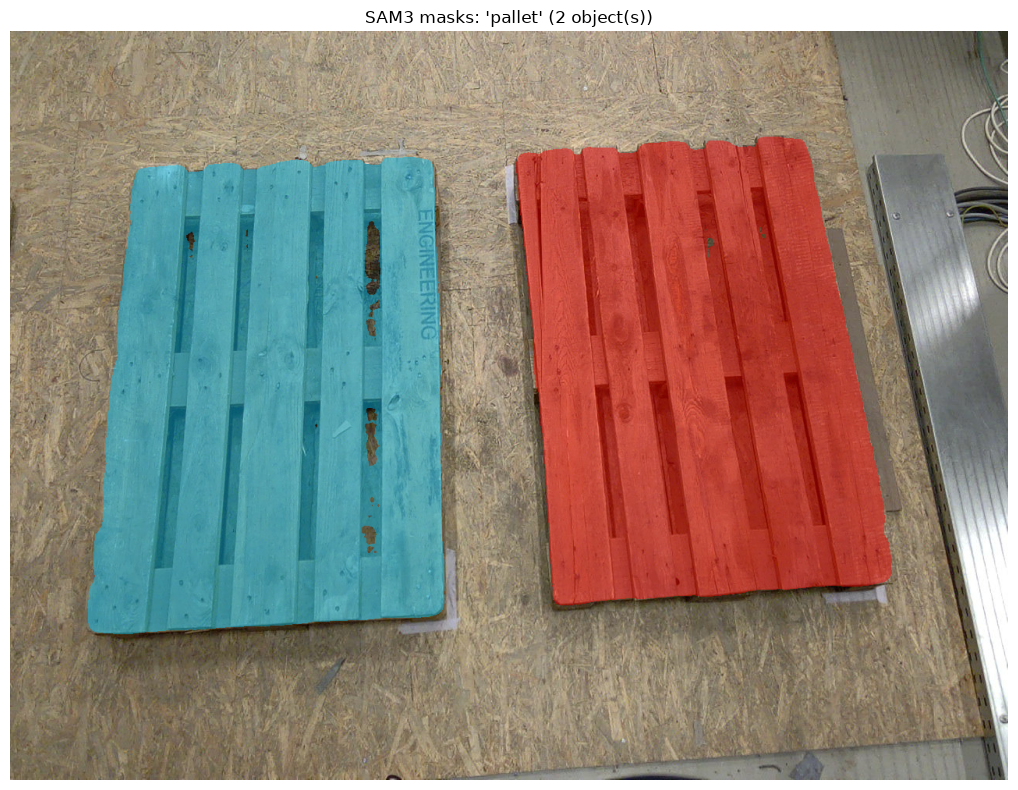

In [23]:
masks_np = extract_masks_from_inference(inference_state)
print(f"✓ Extracted {len(masks_np)} mask(s)")

IMAGE_RESULT_DIR.mkdir(parents=True, exist_ok=True)

# Distinct colors (RGB) cycled per object
MASK_COLORS = [(255, 0, 0), (0, 200, 255), (0, 255, 80), (255, 165, 0), (180, 0, 255)]

# Resize each mask independently — keep separate for per-object OBB fitting
resized_binary_masks = []
for mask in masks_np:
    mask_img = Image.fromarray((mask > 0).astype(np.uint8) * 255, mode="L")
    if mask_img.size != image.size:
        mask_img = mask_img.resize(image.size, Image.NEAREST)
    resized_binary_masks.append(np.asarray(mask_img) > 0)

print(f"✓ {len(resized_binary_masks)} object mask(s) ready")

# Show overlay with a distinct color per object
overlay = np.asarray(image).copy()
for i, mask in enumerate(resized_binary_masks):
    color = np.array(MASK_COLORS[i % len(MASK_COLORS)], dtype=np.float32)
    overlay[mask] = (overlay[mask] * 0.55 + color * 0.45).astype(np.uint8)

plt.figure(figsize=(12, 8))
plt.imshow(overlay)
plt.title(f"SAM3 masks: '{NAMING_PROMPT}' ({len(resized_binary_masks)} object(s))")
plt.axis("off")
plt.tight_layout()
plt.show()

## 3D OBB from Mask

Image → SAM3 mask → back-project mask pixels to 3D (depth + intrinsics) → Fit OBB

In [24]:
fx = CAMERA_INTRINSICS['fx']
fy = CAMERA_INTRINSICS['fy']
cx = CAMERA_INTRINSICS['cx']
cy = CAMERA_INTRINSICS['cy']
img_w = CAMERA_INTRINSICS['width']
img_h = CAMERA_INTRINSICS['height']

obbs = []
poses = []
MIN_POINTS_FOR_OBB = 100

for i, mask in enumerate(resized_binary_masks):
    print(f"\n-- Object {i} {'-' * 36}")

    # Step 1: mask pixels -> 3D points
    ys, xs = np.where(mask)
    Z = depth_mm[ys, xs].astype(float)
    valid = Z > 0
    ys, xs, Z = ys[valid], xs[valid], Z[valid]

    if len(Z) < MIN_POINTS_FOR_OBB:
        print(f"  ! Skipping object {i}: too few valid depth points ({len(Z)})")
        continue

    X = (xs - cx) * Z / fx
    Y = (ys - cy) * Z / fy
    points_3d = np.stack([X, Y, Z], axis=1)
    print(f"  Mask pixels with valid depth: {len(points_3d):,}")

    # Step 2: remove outliers
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points_3d)
    pcd, _ = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
    print(f"  After outlier removal:        {len(pcd.points):,} points")

    if len(pcd.points) < MIN_POINTS_FOR_OBB:
        print(f"  ! Skipping object {i}: too few points after filtering")
        continue

    # Step 2b: save segmented point cloud
    pcd_path = IMAGE_RESULT_DIR / f"{NAMING_PROMPT.replace(' ', '_')}_segment_{i:02d}.ply"
    o3d.io.write_point_cloud(str(pcd_path), pcd)
    print(f"  Saved point cloud: {pcd_path.name}")

    # Step 3: fit minimal OBB and derive pose
    obb = pcd.get_minimal_oriented_bounding_box(robust=True)

    pose = obb_to_pose(obb)
    pose = canonicalize_pallet_pose(pose)

    # Override OBB corners with contour-based 2D->3D corners.
    _corner_pixels = extract_corner_coordinates(mask, CORNER_EPSILON_FACTOR)
    _corners_3d = pixel_to_3d(_corner_pixels, depth_mm, CAMERA_INTRINSICS)
    print(f"  Contour corners found: {len(_corners_3d)}")
    for ci, (px, pt3d) in enumerate(zip(_corner_pixels, _corners_3d)):
        print(f"    [{ci}] pixel=({int(px[1])},{int(px[0])})  3D=({pt3d[0]:.1f}, {pt3d[1]:.1f}, {pt3d[2]:.1f}) mm")

    # Filter: require exactly 4 corners all within the image frame.
    if REQUIRE_FULL_VISIBILITY:
        if len(_corners_3d) != 4:
            print(f"  ! Skipping object {i}: {len(_corners_3d)} corner(s) found, need exactly 4")
            continue
        corner_uvs = project_to_2d(_corners_3d, CAMERA_INTRINSICS)
        all_in_frame = all(
            0 <= u < img_w and 0 <= v < img_h
            for u, v in corner_uvs
        )
        if not all_in_frame:
            print(f"  ! Skipping object {i}: one or more corners outside image frame")
            continue

    if len(_corners_3d) > 0:
        pose["corners_3d"] = _corners_3d

    # Keep axis length moderate for corner-origin overlays to remain visible.
    pose["axis_length_mm"] = float(np.clip(0.18 * np.max(pose["extent"]), 80.0, 220.0))
    pose["object_index"] = int(i)
    pose["point_cloud_path"] = str(pcd_path)

    corner_origin = select_origin_corner(pose["corners_3d"])
    if corner_origin is None:
        pose["origin_point"] = pose["center"]
        pose["origin_type"] = "center_fallback"
    else:
        pose["origin_point"] = corner_origin
        pose["origin_type"] = "selected_origin_corner"

    # Store projected corners for overlay diagnostics.
    corners_uv, corners_valid = project_points_to_image(pose["corners_3d"], CAMERA_INTRINSICS)
    pose["corners_uv"] = corners_uv
    pose["corners_valid"] = corners_valid

    # Determine which corner index was selected as origin.
    diffs = np.linalg.norm(pose["corners_3d"] - pose["origin_point"], axis=1)
    selected_corner_idx = int(np.argmin(diffs))
    pose["selected_corner_idx"] = selected_corner_idx

    # Recompute rotation from contour edge vectors so axes align with pallet edges.
    if len(pose["corners_3d"]) >= 3 and pose["origin_type"] == "selected_origin_corner":
        corners = np.asarray(pose["corners_3d"], dtype=np.float64)
        n = len(corners)
        origin = pose["origin_point"]
        adj1 = corners[(selected_corner_idx + 1) % n]
        adj2 = corners[(selected_corner_idx - 1) % n]
        edge1 = adj1 - origin
        edge2 = adj2 - origin
        len1, len2 = np.linalg.norm(edge1), np.linalg.norm(edge2)
        if len1 > 1e-6 and len2 > 1e-6:
            # X = longer edge, Y = shorter edge
            if len1 >= len2:
                x_ax, y_ax = edge1 / len1, edge2 / len2
            else:
                x_ax, y_ax = edge2 / len2, edge1 / len1
            z_ax = np.cross(x_ax, y_ax)
            z_ax /= np.linalg.norm(z_ax)
            if z_ax[2] > 0:  # ensure normal faces camera (Z < 0 in camera space)
                z_ax = -z_ax
            y_ax = np.cross(z_ax, x_ax)
            y_ax /= np.linalg.norm(y_ax)
            pose["rotation"] = np.stack([x_ax, y_ax, z_ax], axis=1)

    # Save a visual-debug point cloud with corners + center + origin + selected corner.
    debug_points = [np.asarray(pose["corners_3d"], dtype=np.float64)]
    debug_colors = [np.tile(np.array([[220, 220, 220]], dtype=np.float64), (len(pose["corners_3d"]), 1))]

    center_pt = np.asarray(pose["center"], dtype=np.float64)[None, :]
    origin_pt = np.asarray(pose["origin_point"], dtype=np.float64)[None, :]
    debug_points.extend([center_pt, origin_pt])
    debug_colors.extend([
        np.array([[0, 255, 0]], dtype=np.float64),
        np.array([[0, 0, 255]], dtype=np.float64),
    ])

    if 0 <= selected_corner_idx < len(pose["corners_3d"]):
        selected_corner_pt = np.asarray(pose["corners_3d"][selected_corner_idx], dtype=np.float64)[None, :]
        debug_points.append(selected_corner_pt)
        debug_colors.append(np.array([[255, 0, 0]], dtype=np.float64))

    debug_points = np.vstack(debug_points)
    debug_colors = np.vstack(debug_colors)
    pose_points_path = IMAGE_RESULT_DIR / f"{NAMING_PROMPT.replace(' ', '_')}_pose_points_{i:02d}.ply"
    save_points_cloud(debug_points, debug_colors, pose_points_path)
    pose["pose_points_path"] = str(pose_points_path)

    obbs.append(obb)
    poses.append(pose)

    center_uv, center_valid = project_points_to_image(pose["center"][None, :], CAMERA_INTRINSICS)
    origin_uv, origin_valid = project_points_to_image(pose["origin_point"][None, :], CAMERA_INTRINSICS)

    print(f"  center : {pose['center'].round(1)}")
    print(f"  extent (x=long, y=short, z=height) : {pose['extent'].round(1)} mm")
    print(f"  volume : {pose['volume_liters']:.3f} L")
    print(f"  axis_length_mm : {pose['axis_length_mm']:.1f}")
    print(f"  origin : {pose['origin_type']}")
    if bool(center_valid[0]):
        print(f"  center_uv : {tuple(center_uv[0].tolist())}")
    if bool(origin_valid[0]):
        print(f"  origin_uv : {tuple(origin_uv[0].tolist())}")
    print(f"  selected_corner_idx : {selected_corner_idx}")
    print(f"  Saved pose points: {pose_points_path.name}")

    # Step 4: save OBB mesh
    box_mesh = o3d.geometry.TriangleMesh.create_from_oriented_bounding_box(obb)
    box_mesh.paint_uniform_color([1.0, 1.0, 1.0])
    mesh_path = IMAGE_RESULT_DIR / f"{NAMING_PROMPT.replace(' ', '_')}_obb_mesh_{i:02d}.ply"
    o3d.io.write_triangle_mesh(str(mesh_path), box_mesh)
    poses[-1]["mesh_path"] = str(mesh_path)
    print(f"  Saved mesh: {mesh_path.name}")

print(f"\nFitted {len(obbs)} OBB(s)")
print(f"Collected {len(poses)} pose record(s)")



-- Object 0 ------------------------------------
  Mask pixels with valid depth: 234,964
  After outlier removal:        225,146 points
  Saved point cloud: pallet_segment_00.ply
  Contour corners found: 4
    [0] pixel=(1015,139)  3D=(814.8, -769.6, 2560.0) mm
    [1] pixel=(652,160)  3D=(-19.8, -712.9, 2530.0) mm
    [2] pixel=(700,733)  3D=(71.5, 472.0, 2025.0) mm
    [3] pixel=(1129,697)  3D=(864.9, 412.7, 2056.0) mm
  center : [ 450.  -166.8 2284.1]
  extent (x=long, y=short, z=height) : [1337.4  882.6  205.7] mm
  volume : 242.806 L
  axis_length_mm : 220.0
  origin : selected_origin_corner
  center_uv : (879, 392)
  origin_uv : (1129, 697)
  selected_corner_idx : 3
  Saved pose points: pallet_pose_points_00.ply
  Saved mesh: pallet_obb_mesh_00.ply

-- Object 1 ------------------------------------
  Mask pixels with valid depth: 245,982
  After outlier removal:        235,176 points
  Saved point cloud: pallet_segment_01.ply
  Contour corners found: 4
    [0] pixel=(537,165)  3D

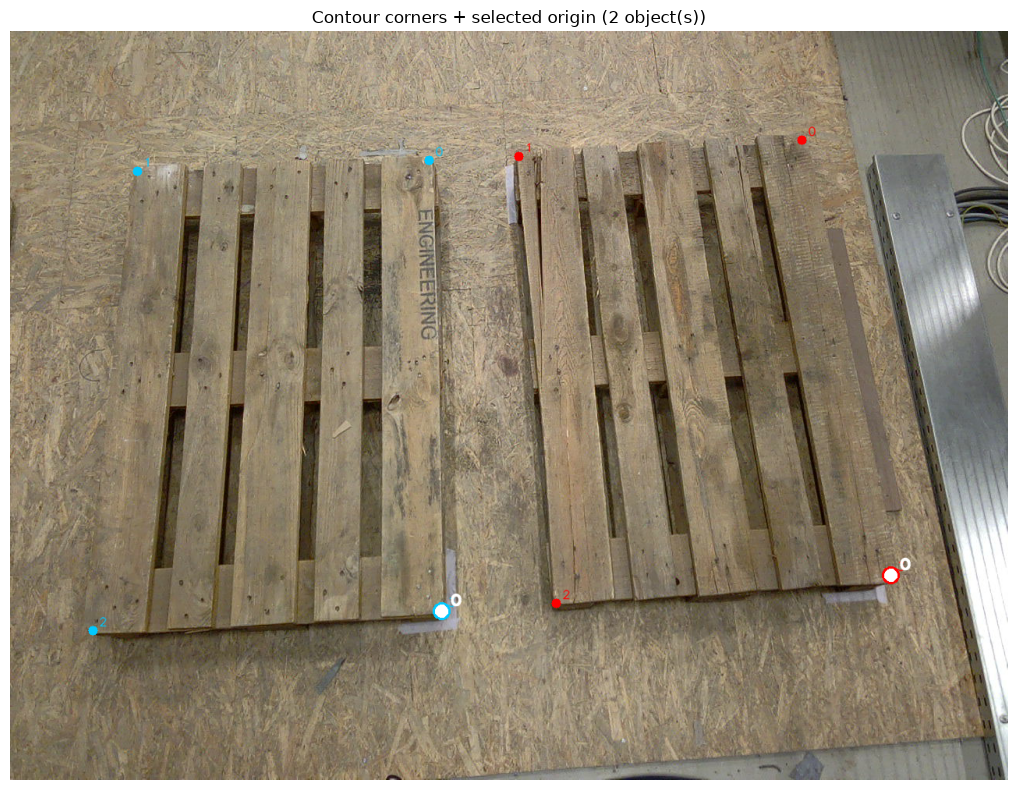

Saved corners overlay: data/picaulo/capture4/outputs/pallet_corners_rgb.png


In [25]:
# Draw contour corner points and the selected origin on the RGB image.
corner_vis = np.asarray(image).copy()
corner_vis_bgr = cv2.cvtColor(corner_vis, cv2.COLOR_RGB2BGR)

for pose in poses:
    obj_idx = pose["object_index"]
    color_bgr = [int(c) for c in np.array(MASK_COLORS[obj_idx % len(MASK_COLORS)])[::-1]]

    # Draw all contour corners as small circles.
    corners_uv = np.asarray(pose["corners_uv"])
    corners_valid = np.asarray(pose["corners_valid"])
    for ci, (uv_pt, vis) in enumerate(zip(corners_uv, corners_valid)):
        if not vis:
            continue
        cv2.circle(corner_vis_bgr, tuple(uv_pt.tolist()), 6, color_bgr, -1)
        cv2.putText(corner_vis_bgr, str(ci), (uv_pt[0] + 8, uv_pt[1] - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color_bgr, 1, cv2.LINE_AA)

    # Draw the selected origin corner as a larger white-filled circle with border.
    origin_uv, origin_valid = project_points_to_image(
        pose["origin_point"][None, :], CAMERA_INTRINSICS
    )
    if bool(origin_valid[0]):
        op = tuple(origin_uv[0].tolist())
        cv2.circle(corner_vis_bgr, op, 10, (255, 255, 255), -1)
        cv2.circle(corner_vis_bgr, op, 10, color_bgr, 2)
        cv2.putText(corner_vis_bgr, "O", (op[0] + 12, op[1] - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)

corner_vis_rgb = cv2.cvtColor(corner_vis_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(corner_vis_rgb)
plt.title(f"Contour corners + selected origin ({len(poses)} object(s))")
plt.axis("off")
plt.tight_layout()
plt.show()

corner_vis_path = IMAGE_RESULT_DIR / f"{NAMING_PROMPT.replace(' ', '_')}_corners_rgb.png"
cv2.imwrite(str(corner_vis_path), corner_vis_bgr)
print(f"Saved corners overlay: {corner_vis_path}")


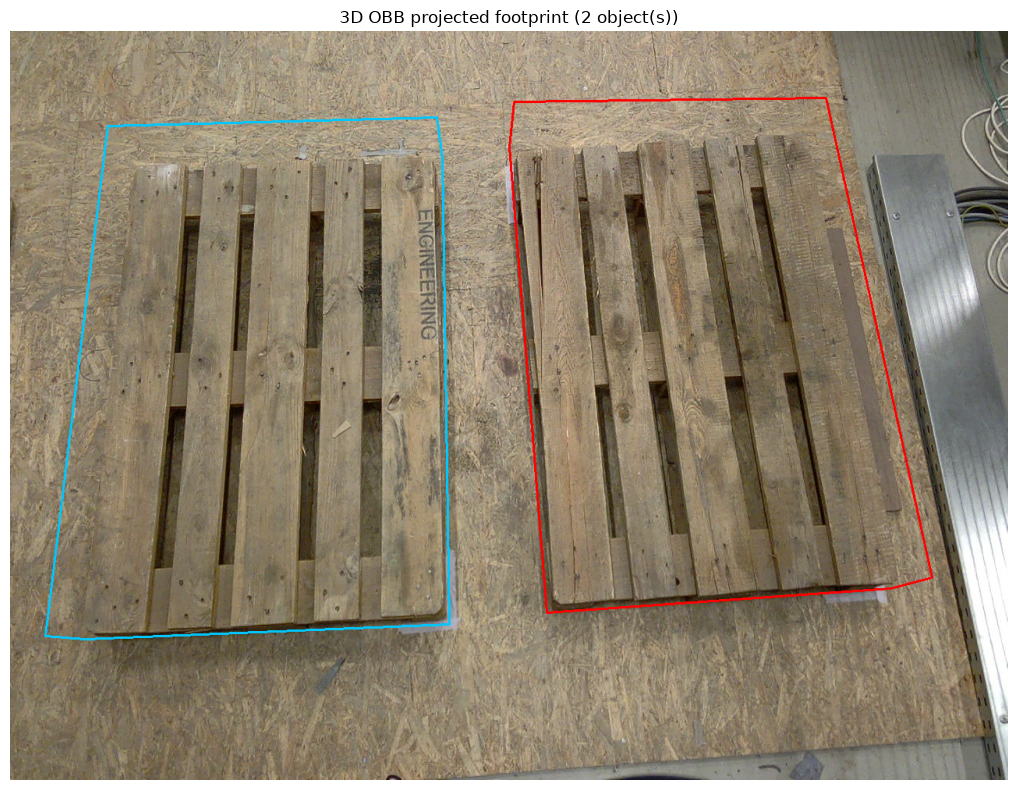

In [26]:
# Project 3D OBB corners to image and draw their 2D convex hull.
obb_vis = np.asarray(image).copy()
obb_vis_bgr = cv2.cvtColor(obb_vis, cv2.COLOR_RGB2BGR)

for idx, obb in enumerate(obbs):
    box_pts = np.asarray(obb.get_box_points(), dtype=np.float64)
    uv, valid = project_points_to_image(box_pts, CAMERA_INTRINSICS)
    pts_2d = uv[valid].reshape(-1, 1, 2).astype(np.int32)
    if len(pts_2d) < 3:
        continue
    hull = cv2.convexHull(pts_2d)
    color = [int(c) for c in np.array(MASK_COLORS[idx % len(MASK_COLORS)])[::-1]]  # RGB->BGR
    cv2.drawContours(obb_vis_bgr, [hull], 0, color, 2)

obb_vis_rgb = cv2.cvtColor(obb_vis_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(obb_vis_rgb)
plt.title(f"3D OBB projected footprint ({len(obbs)} object(s))")
plt.axis("off")
plt.tight_layout()
plt.show()


## Pose Overlay on RGB

Draw object coordinate axes on the RGB image using OBB-derived pose.

Axis colors follow OpenCV BGR drawing convention:
- X axis: red
- Y axis: green
- Z axis: blue

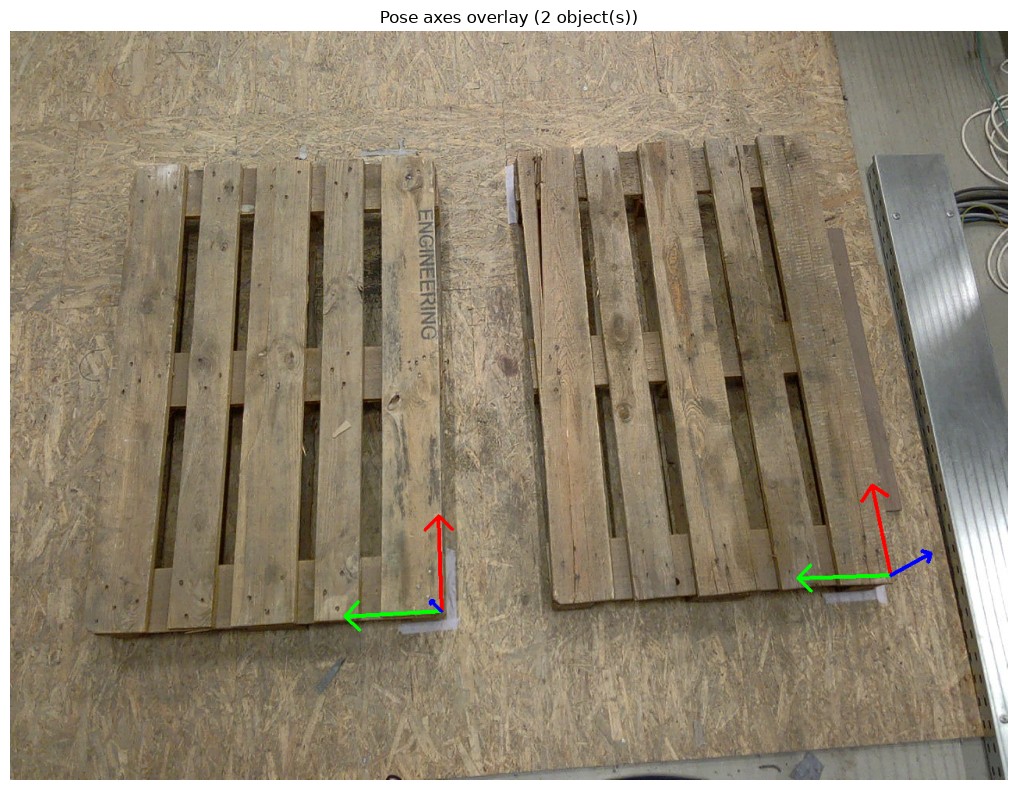

Saved RGB pose overlay: data/picaulo/capture4/outputs/pallet_pose_axes_rgb.png


In [27]:
rgb_bgr = cv2.cvtColor(np.asarray(image), cv2.COLOR_RGB2BGR)
pose_rgb_bgr = rgb_bgr.copy()

for pose in poses:
    axes_3d = build_pose_axes_points(
        center=pose["center"],
        rotation=pose["rotation"],
        axis_length_mm=pose["axis_length_mm"],
        origin_point=pose.get("origin_point"),
    )

    # Keep only XYZ arrows without debug corner/center/origin markers.
    pose_rgb_bgr = draw_pose_axes_on_image(
        image_bgr=pose_rgb_bgr,
        axes_3d=axes_3d,
        intrinsics=CAMERA_INTRINSICS,
        label=None,
        thickness=3,
    )

pose_rgb = cv2.cvtColor(pose_rgb_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(pose_rgb)
plt.title(f"Pose axes overlay ({len(poses)} object(s))")
plt.axis("off")
plt.tight_layout()
plt.show()

pose_rgb_path = IMAGE_RESULT_DIR / f"{NAMING_PROMPT.replace(' ', '_')}_pose_axes_rgb.png"
cv2.imwrite(str(pose_rgb_path), pose_rgb_bgr)
print(f"Saved RGB pose overlay: {pose_rgb_path}")

## Save Pose to JSON

Export per-object pose values (translation + rotation matrix) to a JSON file.

In [28]:
import json

poses_json = []
for pose in poses:
    corners_3d = np.asarray(pose["corners_3d"], dtype=float)
    corners_uv = np.asarray(pose.get("corners_uv"), dtype=int)
    corners_valid = np.asarray(pose.get("corners_valid"), dtype=bool)
    selected_corner_idx = int(pose.get("selected_corner_idx", -1))

    selected_corner_3d = None
    selected_corner_uv = None
    if 0 <= selected_corner_idx < len(corners_3d):
        selected_corner_3d = corners_3d[selected_corner_idx].tolist()
    if 0 <= selected_corner_idx < len(corners_uv):
        selected_corner_uv = corners_uv[selected_corner_idx].tolist()

    poses_json.append(
        {
            "object_index": int(pose.get("object_index", -1)),
            "frame": "camera",
            "translation_center_mm": np.asarray(pose["center"], dtype=float).tolist(),
            "translation_origin_mm": np.asarray(pose["origin_point"], dtype=float).tolist(),
            "rotation_cam_from_obj": np.asarray(pose["rotation"], dtype=float).tolist(),
            "extent_mm": np.asarray(pose["extent"], dtype=float).tolist(),
            "volume_liters": float(pose["volume_liters"]),
            "axis_length_mm": float(pose["axis_length_mm"]),
            "origin_type": str(pose.get("origin_type", "unknown")),
            "selected_corner_idx": selected_corner_idx,
            "selected_corner_3d_mm": selected_corner_3d,
            "selected_corner_uv_px": selected_corner_uv,
            "corners_3d_mm": corners_3d.tolist(),
            "corners_uv_px": corners_uv.tolist(),
            "corners_visible": corners_valid.tolist(),
            "pose_points_path": str(pose.get("pose_points_path", "")),
            "point_cloud_path": str(pose.get("point_cloud_path", "")),
            "mesh_path": str(pose.get("mesh_path", "")),
        }
    )

pose_export = {
    "camera_intrinsics": CAMERA_INTRINSICS,
    "prompt": NAMING_PROMPT,
    "num_objects": len(poses_json),
    "poses": poses_json,
}

pose_json_path = IMAGE_RESULT_DIR / f"{NAMING_PROMPT.replace(' ', '_')}_poses.json"
with open(pose_json_path, "w", encoding="utf-8") as f:
    json.dump(pose_export, f, indent=2)

print(f"Saved pose JSON: {pose_json_path}")

Saved pose JSON: data/picaulo/capture4/outputs/pallet_poses.json
